In [1]:
import os, json, math, time, inspect
from pathlib import Path
from typing import Dict, Optional, Tuple
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from sklearn.metrics import r2_score

from neuralop.layers.gno_block import GNOBlock
from neuralop.models import FNO

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

REPO_ROOT = Path.cwd()
RESULTS_DIR = REPO_ROOT / "Pt_Model/sharedlatent_GINO_4"
PLOT_DIR = REPO_ROOT / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_PATH = RESULTS_DIR / "gino_evolution_sharedlatent_4_best_model.pt"
DATASET_PATH = REPO_ROOT / "Processed_Data" / "processed_data_split3/particle_evolution_dataset.npz"

RUN_TAG = "gino_evolution_sharedlatent_4"
HISTORY_PATH = RESULTS_DIR / f"{RUN_TAG}_history.json"

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Dataset:    {DATASET_PATH}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Device: cuda
Checkpoint: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/Pt_Model/sharedlatent_GINO_4/gino_evolution_sharedlatent_4_best_model.pt
Dataset:    /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/Processed_Data/processed_data_split3/particle_evolution_dataset.npz


In [2]:
import matplotlib as mpl

NEURIPS_SINGLE = (3.25, 2.4)
NEURIPS_FULL   = (6.75, 3.4)

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linewidth": 0.5,
    "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.2, "lines.markersize": 3.2,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size": 3, "ytick.major.size": 3,
})

CB = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
      "red": "#D55E00", "purple": "#CC79A7",
      "sky": "#56B4E9", "grey": "#999999"}

In [3]:
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
cfg = checkpoint["config"]

data = np.load(DATASET_PATH, allow_pickle=True)

inputs_t            = np.asarray(data["inputs_t"], dtype=np.float32)
targets_delta_norm  = np.asarray(
    data["targets_residual_norm" if "targets_residual_norm" in data.files else "targets_delta_norm"],
    dtype=np.float32
)
targets_delta_raw   = np.asarray(data["targets_delta"], dtype=np.float32)

feature_names_all = [str(x) for x in data["feature_names"].tolist()]
feature_names      = checkpoint["feature_names"]
target_names       = checkpoint["target_names"]
field_target_names = checkpoint["field_target_names"]

active_input_indices = [feature_names_all.index(n) for n in feature_names]
coord_indices        = [feature_names_all.index(n) for n in ("x", "y", "z")]
velocity_indices     = [feature_names_all.index(n) for n in ("u_x", "u_y", "u_z")]
gradient_indices     = [feature_names_all.index(f"gradU_{i}{j}") for i in "xyz" for j in "xyz"]
state_indices        = [feature_names_all.index(n) for n in ("x", "y", "z", "Gamma_x", "Gamma_y", "Gamma_z", "sigma")]

input_mean  = checkpoint["input_mean"]
input_std   = checkpoint["input_std"]
target_mean = checkpoint.get("target_mean", data["residual_mean" if "residual_mean" in data.files else "out_mean"])
target_std  = checkpoint.get("target_std",  data["residual_std"  if "residual_std"  in data.files else "out_std"])
raw_delta_mean = data["raw_delta_mean" if "raw_delta_mean" in data.files else "out_mean"]
raw_delta_std  = data["raw_delta_std"  if "raw_delta_std"  in data.files else "out_std"]
field_mean  = checkpoint["field_mean"]
field_std   = checkpoint["field_std"]
coord_min   = checkpoint["coord_min"]
coord_span  = checkpoint["coord_span"]

frame_ranges   = list(data["pair_ranges"])
frame_contexts = list(data["pair_contexts"])
train_ids = data["train_pair_ids"]
val_ids   = data["val_pair_ids"]
test_ids  = data["test_pair_ids"]

query_coords_all   = data["query_coords"]
targets_field_norm = data["targets_velocity_field_norm"]
field_mask         = data["field_query_mask"]

global_condition_channels = cfg["global_condition_channels"]
delta_channels = len(target_names)
field_channels = len(field_target_names)

print("Features used:", feature_names)
print("Delta targets:", target_names)
print("Field targets:", field_target_names)
print("Test pairs:", len(test_ids))

Features used: ['u_x', 'u_y', 'u_z', 'sigma', 'geom_dist', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'gradU_xx', 'gradU_xy', 'gradU_xz', 'gradU_yx', 'gradU_yy', 'gradU_yz', 'gradU_zx', 'gradU_zy', 'gradU_zz']
Delta targets: ['dx', 'dy', 'dz', 'dGamma_x', 'dGamma_y', 'dGamma_z', 'dsigma']
Field targets: ['u_x', 'u_y', 'u_z', 'dUx_dx', 'dUx_dy', 'dUx_dz', 'dUy_dx', 'dUy_dy', 'dUy_dz', 'dUz_dx', 'dUz_dy', 'dUz_dz']
Test pairs: 300


In [4]:
def as_context(obj):
    if isinstance(obj, dict):
        return obj
    if hasattr(obj, "item"):
        item = obj.item()
        if isinstance(item, dict):
            return item
    return dict(obj)

def make_gnoblock(in_channels, out_channels, radius):
    kwargs = dict(
        in_channels=in_channels,
        out_channels=out_channels,
        coord_dim=3,
        radius=float(radius),
        transform_type="linear",
        reduction="mean",
        pos_embedding_type="transformer",
        pos_embedding_channels=12,
        channel_mlp_layers=[out_channels, out_channels, out_channels],
    )
    accepted = set(inspect.signature(GNOBlock.__init__).parameters)
    if "use_torch_scatter_reduce" in accepted:
        kwargs["use_torch_scatter_reduce"] = False
    if "use_open3d_neighbor_search" in accepted:
        kwargs["use_open3d_neighbor_search"] = False
    return GNOBlock(**{k: v for k, v in kwargs.items() if k in accepted})

def positional_encoding(coords, num_frequencies: int):
    if num_frequencies <= 0:
        return coords
    freqs = (2.0 ** torch.arange(num_frequencies, device=coords.device, dtype=coords.dtype)).view(1, 1, -1)
    angles = coords.unsqueeze(-1) * freqs * math.pi
    return torch.cat([coords, torch.sin(angles).flatten(-2), torch.cos(angles).flatten(-2)], dim=-1)

def euler_baseline_from_batch(batch):
    state_t = torch.tensor(batch["state_phys_raw"], device=DEVICE, dtype=torch.float32)
    u_true = torch.tensor(batch["velocity_phys_raw"], device=DEVICE, dtype=torch.float32)
    gradU_true = torch.tensor(batch["gradU_phys_raw"], device=DEVICE, dtype=torch.float32).reshape(-1, 3, 3)
    dt = torch.tensor(float(batch.get("dt", 0.0034)), device=DEVICE, dtype=torch.float32)
    physics_dx = dt * u_true
    physics_dgamma = dt * torch.einsum("nij,nj->ni", gradU_true, state_t[:, 3:6])
    return state_t, physics_dx, physics_dgamma

def reconstruct_next_state_from_residual(batch, residual_pred_norm):
    residual_pred_phys = residual_pred_norm[:, :7] * target_std_t + target_mean_t
    state_t, physics_dx, physics_dgamma = euler_baseline_from_batch(batch)
    state_tp1_pred = state_t.clone()
    state_tp1_pred[:, :3] += physics_dx + residual_pred_phys[:, :3]
    state_tp1_pred[:, 3:6] += physics_dgamma + residual_pred_phys[:, 3:6]
    state_tp1_pred[:, 6] += residual_pred_phys[:, 6]
    raw_delta = torch.tensor(batch["y_delta_raw"], device=DEVICE, dtype=torch.float32)[:, :7]
    state_tp1_true = state_t + raw_delta
    return state_tp1_pred, state_tp1_true, residual_pred_phys

def state_error_relative_l2(state_pred, state_true):
    """
    Unit‑free state error: mean of per‑channel relative L2 errors.
    Position, circulation and sigma are treated separately.
    """
    eps = 1e-8
    # position (m)
    pos_num = torch.linalg.norm(state_pred[:, :3] - state_true[:, :3], dim=1)
    pos_den = torch.linalg.norm(state_true[:, :3], dim=1).clamp_min(eps)
    pos_err = (pos_num / pos_den).mean()
    # circulation (m²/s)
    circ_num = torch.linalg.norm(state_pred[:, 3:6] - state_true[:, 3:6], dim=1)
    circ_den = torch.linalg.norm(state_true[:, 3:6], dim=1).clamp_min(eps)
    circ_err = (circ_num / circ_den).mean()
    # sigma (m)
    sigma_num = torch.abs(state_pred[:, 6] - state_true[:, 6])
    sigma_den = torch.abs(state_true[:, 6]).clamp_min(eps)
    sigma_err = (sigma_num / sigma_den).mean()
    return (pos_err + circ_err + sigma_err) / 3.0

In [5]:
# --- GINOSharedLatent (exact replication of the trained model) ---
class GINOSharedLatent(nn.Module):
    def __init__(self, in_channels, delta_channels, field_channels, global_channels, cfg):
        super().__init__()
        hidden = int(cfg["hidden_channels"])
        self.latent_res = int(cfg["latent_res"])
        self.query_pe_freqs = int(cfg["query_pos_encoding_frequencies"])
        self.hidden = hidden

        # Shared encoder
        self.lift = nn.Sequential(
            nn.Linear(in_channels, hidden), nn.GELU(),
            nn.Linear(hidden, hidden)
        )
        self.global_condition_mlp = nn.Sequential(
            nn.Linear(global_channels, hidden), nn.GELU(),
            nn.Linear(hidden, hidden)
        )
        self.encoder = make_gnoblock(hidden, hidden, cfg["gno_radius"])

        # FNO processor
        modes = min(int(cfg["fno_modes"]), max(self.latent_res // 2, 1))
        self.fno = FNO(
            n_modes=(modes, modes, modes),
            in_channels=hidden, out_channels=hidden,
            hidden_channels=hidden, n_layers=int(cfg["fno_layers"]),
            positional_embedding=None
        )

        # ---------- Field decoder (MLP) ----------
        query_dim = 3 + 2 * 3 * self.query_pe_freqs
        self.particle_pos_enc_proj = nn.Linear(query_dim, hidden)
        self.grid_pos_enc_proj = nn.Linear(query_dim, hidden)
        width = int(cfg["mlp_hidden"])
        layers = []
        for i in range(int(cfg["mlp_layers"])):
            layers += [nn.Linear((hidden + query_dim) if i == 0 else width, width), nn.GELU()]
        layers.append(nn.Linear(width, field_channels))
        self.field_decoder = nn.Sequential(*layers)

        # ---------- Delta decoder (cross‑attention) ----------
        self.particle_skip_proj = nn.Linear(hidden, hidden)
        self.particle_query_proj = nn.Linear(hidden, hidden)
        self.grid_kv_proj = nn.Linear(hidden, 2 * hidden)
        self.attn_dropout = nn.Dropout(0.0)
        self.attn_norm = nn.LayerNorm(hidden)
        self.delta_fusion = nn.Sequential(
            nn.Linear(2 * hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden)
        )
        self.delta_head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, delta_channels)
        )

        # Uncertainty weights
        self.log_delta_var = nn.Parameter(torch.zeros(()))
        self.log_field_var = nn.Parameter(torch.zeros(()))

    def apply_gno(self, block, source_coords, query_coords, source_features):
        return block(y=source_coords, x=query_coords, f_y=source_features)

    def encode_process(self, input_geom, latent_queries, x, global_params):
        base_latent = latent_queries[0]
        r = self.latent_res
        grids, flat_latents, particle_skips = [], [], []
        for b in range(x.shape[0]):
            h_raw = self.lift(x[b])
            latent = self.apply_gno(self.encoder,
                                    source_coords=input_geom[b],
                                    query_coords=base_latent,
                                    source_features=h_raw)
            if latent.ndim == 3:
                latent = latent.squeeze(0)
            grid = latent.reshape(r, r, r, -1).permute(3, 0, 1, 2).unsqueeze(0)
            cond = self.global_condition_mlp(global_params[b]).view(1, -1, 1, 1, 1)
            processed_grid = self.fno(grid + cond)
            processed_flat = processed_grid.squeeze(0).permute(1, 2, 3, 0).reshape(-1, processed_grid.shape[1])
            grids.append(processed_grid)
            flat_latents.append(processed_flat)
            particle_skips.append(self.particle_skip_proj(h_raw))
        return base_latent, grids, flat_latents, particle_skips

    def sample_grid(self, grid, queries):
        q = queries.clamp(0.0, 1.0)
        sample_grid = (q * 2.0 - 1.0).view(1, -1, 1, 1, 3)
        sampled = torch.nn.functional.grid_sample(grid, sample_grid,
                                                  align_corners=True, mode="bilinear")
        return sampled.squeeze(0).squeeze(-1).squeeze(-1).transpose(0, 1)

    def cross_attention(self, queries, keys, values):
        d = queries.shape[-1]
        scores = torch.matmul(queries, keys.transpose(-2, -1)) / math.sqrt(d)
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        return torch.matmul(attn_weights, values)

    def forward(self, input_geom, latent_queries, output_queries, x, global_params):
        base_latent, grids, flat_latents, particle_skips = self.encode_process(
            input_geom, latent_queries, x, global_params)
        delta_outputs, field_outputs = [], []
        for b, (grid, flat_latent, skip) in enumerate(zip(grids, flat_latents, particle_skips)):
            # --- Delta decoder (cross‑attention) ---
            pos_enc = positional_encoding(input_geom[b].unsqueeze(0), self.query_pe_freqs).squeeze(0)
            q_base = skip + self.particle_pos_enc_proj(pos_enc)
            q = self.particle_query_proj(q_base)

            grid_pos_enc = positional_encoding(base_latent.unsqueeze(0), self.query_pe_freqs).squeeze(0)
            kv_input = flat_latent + self.grid_pos_enc_proj(grid_pos_enc)
            kv = self.grid_kv_proj(kv_input)
            k, v = kv[..., :self.hidden], kv[..., self.hidden:]

            particle_latent = self.cross_attention(q, k, v)
            particle_latent = self.attn_norm(particle_latent + q)
            fused = self.delta_fusion(torch.cat([particle_latent, skip], dim=-1))
            delta_outputs.append(self.delta_head(fused).unsqueeze(0))

            # --- Field decoder ---
            q_field = output_queries[b].clamp(0.0, 1.0)
            sampled = self.sample_grid(grid, q_field)
            field_out = self.field_decoder(torch.cat(
                [sampled, positional_encoding(q_field.unsqueeze(0), self.query_pe_freqs).squeeze(0)],
                dim=-1))
            field_outputs.append(field_out.unsqueeze(0))

        return torch.cat(delta_outputs, dim=0), torch.cat(field_outputs, dim=0)


# Helper to create latent grid queries
def make_latent_queries(res, device=DEVICE):
    line = torch.linspace(0.0, 1.0, res, dtype=torch.float32, device=device)
    xx, yy, zz = torch.meshgrid(line, line, line, indexing="ij")
    return torch.stack([xx, yy, zz], dim=-1).reshape(1, -1, 3)


# --- Instantiate model and load weights ---
model = GINOSharedLatent(
    len(feature_names),
    delta_channels,
    field_channels,
    len(global_condition_channels),
    cfg
).to(DEVICE)

state_dict = checkpoint["model_state_dict"]
state_dict.pop("_metadata", None)                # remove non‑parameter key
model.load_state_dict(state_dict, strict=True)
model.eval()

print(f"Loaded {sum(p.numel() for p in model.parameters()):,} parameters.")

Loaded 14,769,173 parameters.


In [6]:
def normalize_xyz(arr):
    return np.clip((arr - coord_min) / coord_span, 0, 1).astype(np.float32)

def context_global_params(ctx):
    ctx = as_context(ctx)
    freestream = np.asarray(ctx.get("freestream", [0, 0, 0])).reshape(-1)
    values = {
        "angle_of_attack": float(ctx.get("aoa_deg", 0)) / 45.0,
        "freestream_magnitude": float(np.linalg.norm(freestream)) / 10.0,
        "phase": float(ctx.get("phase_t", 0)),
    }
    return np.array([values[ch] for ch in global_condition_channels], dtype=np.float32)

def build_batch(pair_id, max_particles=4096, max_queries=4096):
    start, end = int(frame_ranges[pair_id][3]), int(frame_ranges[pair_id][4])
    raw = inputs_t[start:end]

    ctx = as_context(frame_contexts[pair_id])
    case = str(ctx.get("case", "unknown"))
    n_total = raw.shape[0]
    nmin = int(case_to_nmin.get(case, n_total))
    n_use = min(n_total, nmin, max_particles)
    idx = np.arange(n_use, dtype=np.int64)

    x_norm = (raw[idx][:, active_input_indices] - input_mean) / input_std
    x_norm = np.clip(np.nan_to_num(x_norm), -8.0, 8.0).astype(np.float32)
    coord_norm = normalize_xyz(raw[idx][:, coord_indices])

    state_phys = raw[idx][:, state_indices].astype(np.float32)
    velocity_phys = raw[idx][:, velocity_indices].astype(np.float32)
    gradU_phys = raw[idx][:, gradient_indices].astype(np.float32)

    # deterministic query subset – NO random choice
    valid = np.flatnonzero(field_mask[pair_id])
    if len(valid) > max_queries:
        # evenly spaced subset
        query_idx = valid[np.linspace(0, len(valid) - 1, max_queries, dtype=int)]
    else:
        query_idx = valid

    q_xyz = query_coords_all[pair_id, query_idx]
    y_field = targets_field_norm[pair_id, query_idx]

    g_params = context_global_params(ctx)

    y_delta = targets_delta_norm[start:end][idx, :delta_channels]
    y_delta_raw = targets_delta_raw[start:end][idx, :delta_channels]

    return {
        "input_geom": torch.from_numpy(coord_norm).unsqueeze(0).to(DEVICE),
        "x": torch.from_numpy(x_norm).unsqueeze(0).to(DEVICE),
        "output_queries": torch.from_numpy(normalize_xyz(q_xyz)).unsqueeze(0).to(DEVICE),
        "global_params": torch.from_numpy(g_params).unsqueeze(0).to(DEVICE),
        "y_delta_norm": y_delta,
        "y_field_norm": y_field,
        "query_xyz_raw": q_xyz,
        "input_xyz_raw": raw[idx][:, coord_indices],
        "state_phys_raw": state_phys,
        "velocity_phys_raw": velocity_phys,
        "gradU_phys_raw": gradU_phys,
        "y_delta_raw": y_delta_raw,
        "dt": float(ctx.get("dt", 0.0034)),
    }

# Compute case_to_nmin once
case_to_nmin = {}
for pair_id in range(len(frame_ranges)):
    case = str(as_context(frame_contexts[pair_id]).get("case", ""))
    n = int(frame_ranges[pair_id][5])
    if case not in case_to_nmin or n < case_to_nmin[case]:
        case_to_nmin[case] = n
print("case_to_nmin:", case_to_nmin)

case_to_nmin: {'10deg_static_airfoil_10u_1p': 301, '11deg_static_airfoil_10u_1p': 301, '12deg_static_airfoil_10u_1p': 301, '14deg_static_airfoil_10u_1p': 301, '15deg_static_airfoil_10u_1p': 301, '16deg_static_airfoil_10u_1p': 301, '18deg_static_airfoil_10u_1p': 301, '20deg_static_airfoil_10u_1p': 301, '21deg_static_airfoil_10u_1p': 301, '22deg_static_airfoil_10u_1p': 301, '24deg_static_airfoil_10u_1p': 301, '25deg_static_airfoil_10u_1p': 301, '26deg_static_airfoil_10u_1p': 301, '27deg_static_airfoil_10u_1p': 301, '28deg_static_airfoil_10u_1p': 301, '30deg_static_airfoil_10u_1p': 301, '32deg_static_airfoil_10u_1p': 301}


In [7]:
@torch.no_grad()
def evaluate_field_norm_overall(max_pairs=None):
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    pred_all, true_all = [], []
    for pid in ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        _, field_pred = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              batch["output_queries"],
                              batch["x"],
                              batch["global_params"])
        field_pred = field_pred[0]
        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        pred_all.append(field_pred.reshape(-1))
        true_all.append(y_field_norm.reshape(-1))
    pred_all = torch.cat(pred_all)
    true_all = torch.cat(true_all)
    rel = (torch.linalg.norm(pred_all - true_all) /
           torch.linalg.norm(true_all).clamp_min(1e-8)).item()
    return rel

norm_overall = evaluate_field_norm_overall()
print(f"Overall normalised field rel. L2 (12 channels): {norm_overall:.4f}")

@torch.no_grad()
def evaluate_test_set_global(max_pairs=None):
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    state_pred_all, state_true_all = [], []
    field_pred_all, field_true_all = [], []

    for pid in ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, field_pred = model(batch["input_geom"],
                                       make_latent_queries(cfg["latent_res"]),
                                       batch["output_queries"],
                                       batch["x"],
                                       batch["global_params"])
        delta_pred = delta_pred[0]
        field_pred = field_pred[0]

        state_tp1_pred, state_tp1_true, _ = reconstruct_next_state_from_residual(batch, delta_pred)
        state_pred_all.append(state_tp1_pred.reshape(-1))
        state_true_all.append(state_tp1_true.reshape(-1))

        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        field_true_phys = y_field_norm * field_std_t + field_mean_t
        field_pred_phys = field_pred * field_std_t + field_mean_t
        vel_true = field_true_phys[:, :3].reshape(-1)
        vel_pred = field_pred_phys[:, :3].reshape(-1)
        field_pred_all.append(vel_pred)
        field_true_all.append(vel_true)

    state_pred_all = torch.cat(state_pred_all)
    state_true_all = torch.cat(state_true_all)
    field_pred_all = torch.cat(field_pred_all)
    field_true_all = torch.cat(field_true_all)

    state_global = (torch.linalg.norm(state_pred_all - state_true_all) /
                    torch.linalg.norm(state_true_all).clamp_min(1e-8)).item()
    field_global = (torch.linalg.norm(field_pred_all - field_true_all) /
                    torch.linalg.norm(field_true_all).clamp_min(1e-8)).item()
    return state_global, field_global

# Pre‑compute normalisation tensors
field_mean_vel = field_mean[:3]
field_std_vel  = field_std[:3]
target_mean_t = torch.tensor(target_mean[:7], dtype=torch.float32, device=DEVICE)
target_std_t  = torch.tensor(target_std[:7],  dtype=torch.float32, device=DEVICE)
field_mean_t  = torch.tensor(field_mean,       dtype=torch.float32, device=DEVICE)
field_std_t   = torch.tensor(field_std,        dtype=torch.float32, device=DEVICE)

state_glob, field_glob = evaluate_test_set_global()
print(f"State overall physical rel. L2: {state_glob:.4f}")
print(f"Field overall physical rel. L2: {field_glob:.4f}")

Overall normalised field rel. L2 (12 channels): 0.2864
State overall physical rel. L2: 0.0198
Field overall physical rel. L2: 0.1670


/tmp/ipykernel_34835/2080069316.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([state_errs, field_errs],


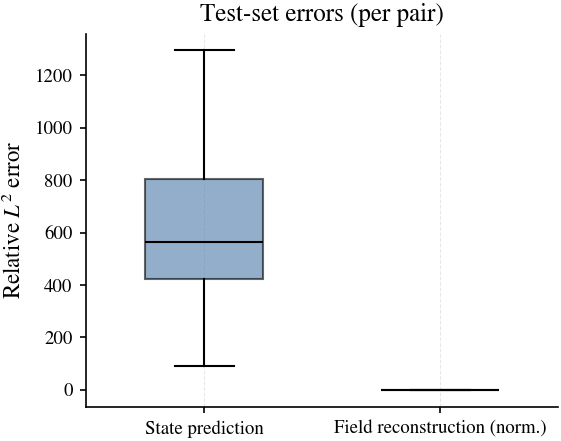

State error: mean=1386.9512, median=565.3601
Field error (norm.): mean=0.2317, median=0.2019


In [8]:
@torch.no_grad()
def evaluate_per_pair(max_pairs=None):
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    state_errors = []
    field_errors_norm = []

    for pid in ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, field_pred = model(batch["input_geom"],
                                       make_latent_queries(cfg["latent_res"]),
                                       batch["output_queries"],
                                       batch["x"],
                                       batch["global_params"])
        delta_pred = delta_pred[0]
        field_pred = field_pred[0]

        state_tp1_pred, state_tp1_true, _ = reconstruct_next_state_from_residual(batch, delta_pred)
        state_err = state_error_relative_l2(state_tp1_pred, state_tp1_true)
        state_errors.append(state_err.item())

        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        field_err = (torch.linalg.norm(field_pred.reshape(-1) - y_field_norm.reshape(-1)) /
                     torch.linalg.norm(y_field_norm.reshape(-1)).clamp_min(1e-8)).item()
        field_errors_norm.append(field_err)

    return np.array(state_errors), np.array(field_errors_norm)

state_errs, field_errs = evaluate_per_pair()

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.0,
    "grid.alpha": 0.3,
})

fig, ax = plt.subplots(figsize=(4, 3.2))
bp = ax.boxplot([state_errs, field_errs],
                labels=["State prediction", "Field reconstruction (norm.)"],
                widths=0.5, showfliers=False,
                patch_artist=True,
                medianprops=dict(color="black"))
for patch, color in zip(bp['boxes'], ["#4c78a8", "#59a14f"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Relative $L^2$ error")
ax.set_title("Test‑set errors (per pair)")
ax.grid(axis="y")
fig.tight_layout()
fig.savefig(PLOT_DIR / "test_rel_error_boxplot.pdf")
plt.show()

print(f"State error: mean={state_errs.mean():.4f}, median={np.median(state_errs):.4f}")
print(f"Field error (norm.): mean={field_errs.mean():.4f}, median={np.median(field_errs):.4f}")

/tmp/ipykernel_34835/1831330956.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
/tmp/ipykernel_34835/1831330956.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],


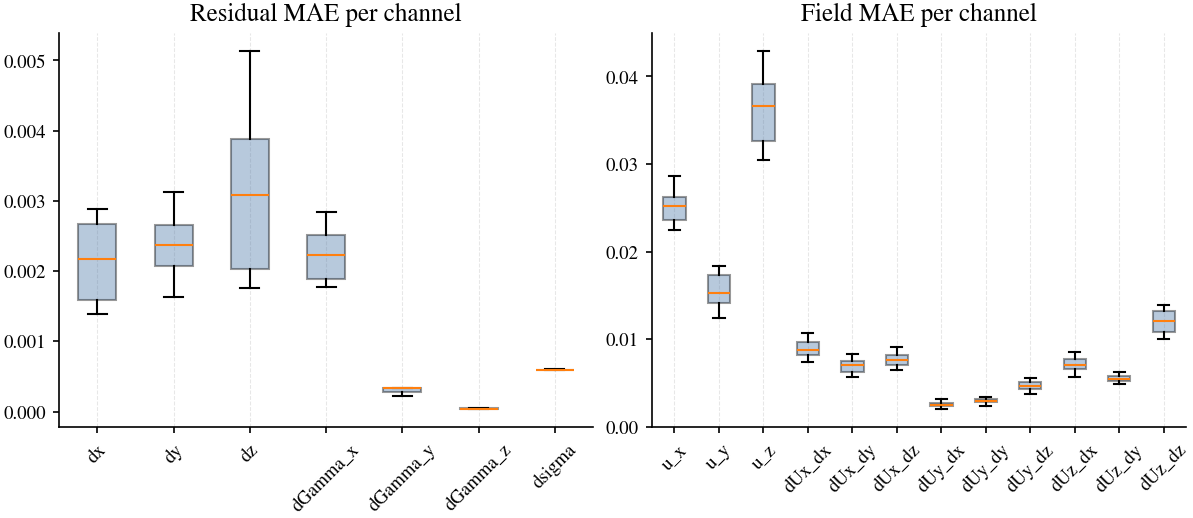

In [9]:
@torch.no_grad()
def channel_wise_mae(max_pairs=20):
    delta_mae, field_mae = [], []
    for pid in test_ids[:max_pairs]:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, field_pred = model(batch["input_geom"],
                                       make_latent_queries(cfg["latent_res"]),
                                       batch["output_queries"],
                                       batch["x"],
                                       batch["global_params"])
        delta_pred = delta_pred[0]
        field_pred = field_pred[0]

        d_pred = (delta_pred * target_std_t + target_mean_t).cpu().numpy()
        y_delta_norm = torch.tensor(batch["y_delta_norm"], device=DEVICE)
        d_true = (y_delta_norm[:, :7] * target_std_t + target_mean_t).cpu().numpy()

        f_pred = (field_pred * field_std_t + field_mean_t).cpu().numpy()
        y_field_norm = torch.tensor(batch["y_field_norm"], device=DEVICE)
        f_true = (y_field_norm * field_std_t + field_mean_t).cpu().numpy()

        delta_mae.append(np.mean(np.abs(d_pred - d_true), axis=0))
        field_mae.append(np.mean(np.abs(f_pred - f_true), axis=0))

    delta_mae = np.stack(delta_mae, axis=0)
    field_mae = np.stack(field_mae, axis=0)
    return delta_mae, field_mae

d_mae, f_mae = channel_wise_mae(max_pairs=20)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
for ax, data, names, title in zip(axes,
    [d_mae, f_mae],
    [target_names, field_target_names],
    ["Residual MAE per channel", "Field MAE per channel"]):
    bp = ax.boxplot([data[:, i] for i in range(data.shape[1])],
                    labels=names, showfliers=False, widths=0.5,
                    patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor("#4c78a8")
        patch.set_alpha(0.4)
    ax.set_title(title)
    ax.grid(axis="y")
    ax.tick_params(axis="x", rotation=45)
fig.savefig(PLOT_DIR / "channel_mae.pdf")
plt.show()

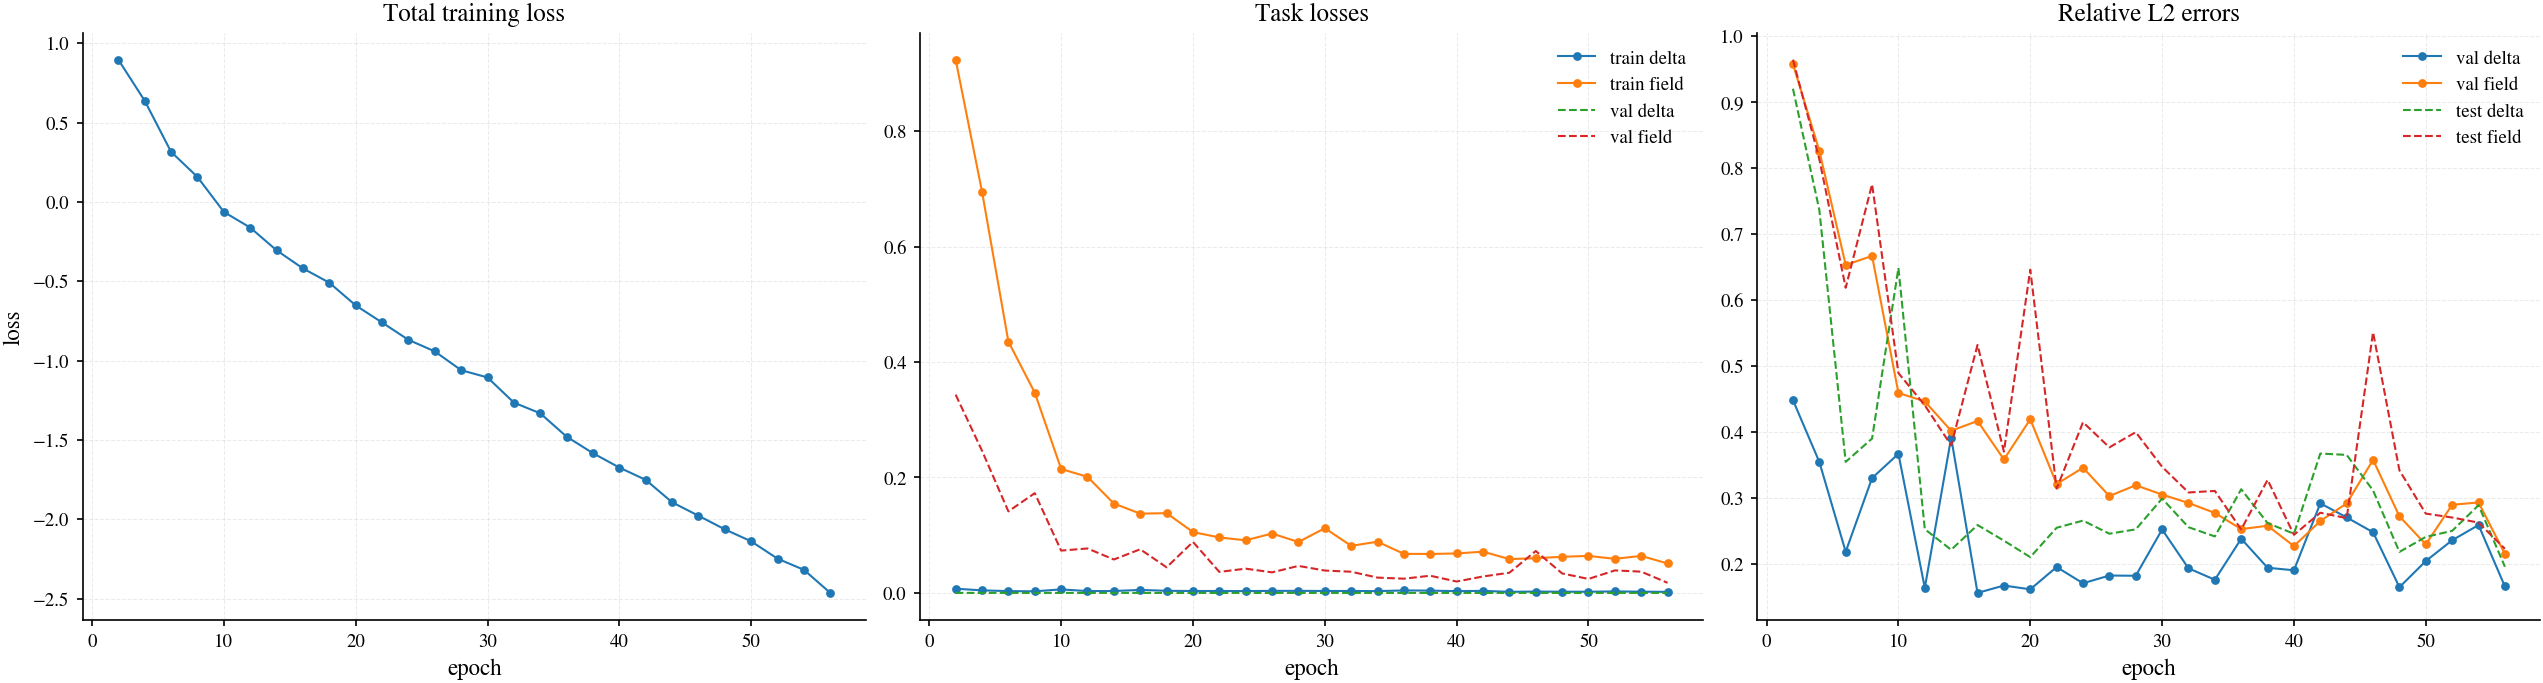

In [10]:
history = checkpoint.get("history", [])
if not history and HISTORY_PATH.exists():
    history = json.loads(HISTORY_PATH.read_text())
if history:
    epochs = np.asarray([row["epoch"] for row in history])
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o")
    axes[0].set_title("Total training loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.25)
    axes[1].plot(epochs, [row.get("train_delta_loss", np.nan) for row in history], marker="o", label="train delta")
    axes[1].plot(epochs, [row.get("train_field_loss", np.nan) for row in history], marker="o", label="train field")
    axes[1].plot(epochs, [row.get("val", {}).get("delta_loss", np.nan) for row in history], "--", label="val delta")
    axes[1].plot(epochs, [row.get("val", {}).get("field_loss", np.nan) for row in history], "--", label="val field")
    axes[1].set_title("Task losses")
    axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.25); axes[1].legend(frameon=False)
    axes[2].plot(epochs, [row.get("val", {}).get("delta_rel_l2", np.nan) for row in history], marker="o", label="val delta")
    axes[2].plot(epochs, [row.get("val", {}).get("field_rel_l2", np.nan) for row in history], marker="o", label="val field")
    axes[2].plot(epochs, [row.get("test", {}).get("delta_rel_l2", np.nan) for row in history], "--", label="test delta")
    axes[2].plot(epochs, [row.get("test", {}).get("field_rel_l2", np.nan) for row in history], "--", label="test field")
    axes[2].set_title("Relative L2 errors")
    axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.25); axes[2].legend(frameon=False)
    fig.savefig(PLOT_DIR / "training_history_losses_errors.png", dpi=220, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_34835/1812784922.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_aoa, labels=labels, widths=0.5, showfliers=False,


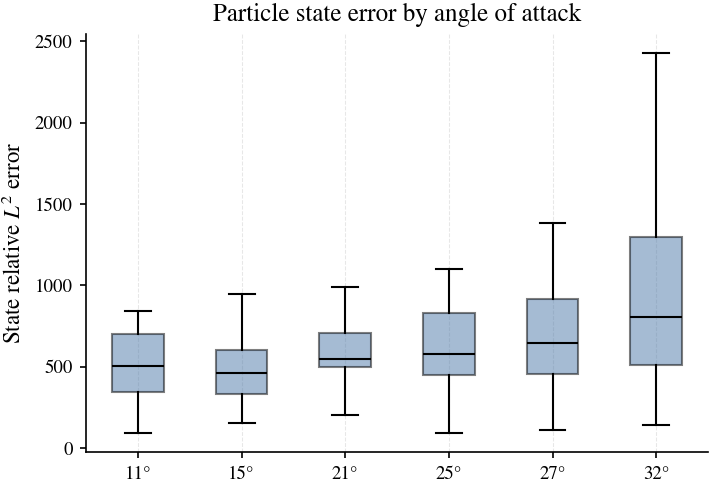

In [11]:
@torch.no_grad()
def state_error_by_aoa(max_pairs=None):
    ids = test_ids[:max_pairs] if max_pairs else test_ids
    errors = defaultdict(list)
    for pid in ids:
        batch = build_batch(pid, max_particles=4096, max_queries=4096)
        delta_pred, _ = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              batch["output_queries"],
                              batch["x"],
                              batch["global_params"])
        delta_pred = delta_pred[0]
        state_tp1_pred, state_tp1_true, _ = reconstruct_next_state_from_residual(batch, delta_pred)
        err = state_error_relative_l2(state_tp1_pred, state_tp1_true).item()
        ctx = as_context(frame_contexts[pid])
        aoa = int(round(float(ctx.get("aoa_deg", 0))))
        errors[aoa].append(err)
    return errors

state_aoa_err = state_error_by_aoa()
aoa_sorted = sorted(state_aoa_err.keys())
data_aoa = [state_aoa_err[a] for a in aoa_sorted]
labels = [f"{a}°" for a in aoa_sorted]

fig, ax = plt.subplots(figsize=(5, 3.5))
bp = ax.boxplot(data_aoa, labels=labels, widths=0.5, showfliers=False,
                patch_artist=True, medianprops=dict(color="black"))
for patch in bp['boxes']:
    patch.set_facecolor("#4c78a8")
    patch.set_alpha(0.5)
ax.set_ylabel("State relative $L^2$ error")
ax.set_title("Particle state error by angle of attack")
ax.grid(axis="y")
fig.tight_layout()
fig.savefig(PLOT_DIR / "state_error_by_aoa.pdf")
plt.show()

NameError: name 'df_evo' is not defined

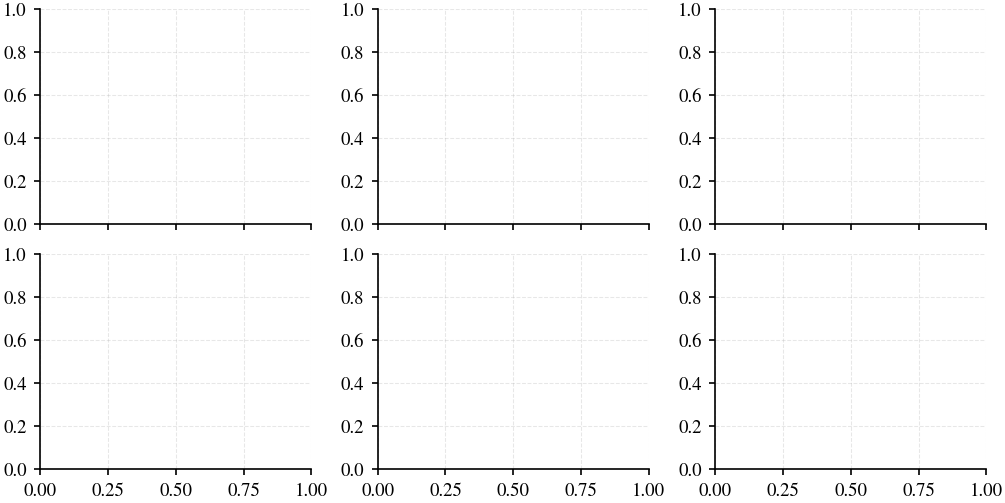

In [13]:
# ------------------------------------------------------------------
# Normalised RMSE per state channel vs phase.
# Rows: AoA = 21° (top) and 32° (bottom).
# Columns: position, circulation, sigma.
# NRMSE = RMSE / RMS(true) — dimensionless, comparable across AoAs.
# Shaded band: ±1 std across pairs sharing the same phase.
# ------------------------------------------------------------------
aoa_left  = 21
aoa_right = 32

states = [("pos_rmse_norm",   "Position"),
          ("circ_rmse_norm",  "Circulation"),
          ("sigma_rmse_norm", "Sigma")]

panels = [(aoa_left,  CB["blue"], "o", "(a)"),
          (aoa_right, CB["red"],  "s", "(b)")]

fig, axes = plt.subplots(2, 3, figsize=(6.75, 3.4),
                         sharex=True, constrained_layout=True)

phase_min = 0.1

for i, (aoa, color, marker, tag) in enumerate(panels):
    df = (df_evo[df_evo["aoa"] == aoa]
          .query("phase >= @phase_min")
          .sort_values("phase"))
    ph = df["phase"].values

    for j, (col, label) in enumerate(states):
        ax = axes[i, j]
        mu = df[col].values
        sd = df.groupby("phase")[col].std().reindex(ph).fillna(0).values

        ax.fill_between(ph, mu - sd, mu + sd, color=color, alpha=0.15, lw=0)
        ax.plot(ph, mu, marker=marker, color=color, lw=1.2,
                markersize=3.2, markerfacecolor="white",
                markeredgewidth=0.8, markeredgecolor=color)

        if i == 0:
            ax.set_title(label, fontsize=9)
        if j == 0:
            ax.set_ylabel(f"AoA = {aoa}°\nNRMSE", fontsize=8)
        if i == 1:
            ax.set_xlabel("Phase", fontsize=9)

    axes[i, 0].text(-0.35, 1.05, tag, transform=axes[i, 0].transAxes,
                    ha="left", va="top", fontweight="bold", fontsize=9)

fig.savefig(PLOT_DIR / "fig_evolution_nrmse.pdf")
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Per-pair relative L2 error: particle state vs. field reconstruction.
# Box = IQR, black diamond = mean, horizontal line = median,
# semi-transparent dots = individual pairs (n ≈ 300).
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.25, 2.4))

bp = ax.boxplot([state_errs, field_errs],
                labels=["State", "Field"],
                widths=0.55, showfliers=False,
                patch_artist=True,
                medianprops=dict(color="black", lw=1.0))

for patch, c in zip(bp["boxes"], [CB["blue"], CB["green"]]):
    patch.set_facecolor(c); patch.set_alpha(0.35)

rng = np.random.default_rng(0)
for i, (d, c) in enumerate(zip([state_errs, field_errs],
                               [CB["blue"], CB["green"]]), start=1):
    x = i + rng.uniform(-0.12, 0.12, size=len(d))
    ax.scatter(x, d, s=2, color=c, alpha=0.35, edgecolors="none")
    ax.scatter([i], [d.mean()], marker="D", s=14,
               color="black", edgecolors="white", lw=0.5, zorder=3)

ax.set_yscale("log")
ax.set_ylabel(r"Relative $L^2$ error")
ax.set_ylim(1e-4, 1e0)
fig.savefig(PLOT_DIR / "fig_test_rel_error.pdf")
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Field slice on the (x, z) plane at the median y of each pair.
# Prediction : evaluated on a dense regular grid  (model is queried anywhere).
# Ground truth: interpolated from the stored scattered query points onto
#               the same regular grid via griddata (linear).
# Both panels share vmin/vmax and fixed axis limits -> directly comparable,
# no auto-zoom artefacts.
# ------------------------------------------------------------------
from scipy.interpolate import griddata

@torch.no_grad()
def plot_field_slice(pair_ids, res=256, n_show=3):
    ids = pair_ids[:n_show]

    # ---- shared colour range ----
    vmax = 0.0
    for pid in ids:
        b = build_batch(pid, max_particles=4096, max_queries=200_000)
        vt = b["y_field_norm"][:, :3] * field_std_t[:3].cpu().numpy() \
             + field_mean_t[:3].cpu().numpy()
        vmax = max(vmax, float(np.linalg.norm(vt, axis=1).max()))
    vmin = 0.0

    x_vals = np.linspace(coord_min[0], coord_min[0] + coord_span[0], res)
    z_vals = np.linspace(coord_min[2], coord_min[2] + coord_span[2], res)
    XX, ZZ = np.meshgrid(x_vals, z_vals)

    fig, axes = plt.subplots(n_show, 2,
                             figsize=(6.75, 1.9 * n_show),
                             constrained_layout=True, squeeze=False)

    for r, pid in enumerate(ids):
        batch = build_batch(pid, max_particles=4096, max_queries=200_000)
        q     = batch["query_xyz_raw"]
        y_mid = float(np.median(batch["input_xyz_raw"][:, 1]))

        # --- prediction on the dense grid ---
        grid_pts = np.stack([XX.ravel(), np.full(XX.size, y_mid), ZZ.ravel()],
                            axis=-1)
        q_norm = torch.from_numpy(normalize_xyz(grid_pts)).unsqueeze(0).to(DEVICE)
        _, field_pred = model(batch["input_geom"],
                              make_latent_queries(cfg["latent_res"]),
                              q_norm, batch["x"], batch["global_params"])
        vp = (field_pred[0][:, :3] * field_std_t[:3] + field_mean_t[:3]).cpu().numpy()
        mag_pred = np.linalg.norm(vp, axis=1).reshape(res, res)

        # --- ground truth: scatter -> grid ---
        vt = batch["y_field_norm"][:, :3] * field_std_t[:3].cpu().numpy() \
             + field_mean_t[:3].cpu().numpy()
        mag_true_sc = np.linalg.norm(vt, axis=1)
        # keep only points in the same y-slab as the grid
        slab = np.abs(q[:, 1] - y_mid) < 0.05 * coord_span[1]
        mag_true = griddata((q[slab, 0], q[slab, 2]), mag_true_sc[slab],
                            (XX, ZZ), method="linear")
        mag_true = np.where(np.isnan(mag_true), np.nan, mag_true)  # keep NaNs

        for c, (mag, tag) in enumerate([(mag_pred, "Prediction"),
                                        (mag_true, "Ground truth")]):
            ax = axes[r, c]
            ax.pcolormesh(XX, ZZ, mag, cmap="viridis",
                          vmin=vmin, vmax=vmax, shading="auto", rasterized=True)
            ax.set_xlim(x_vals[0], x_vals[-1])
            ax.set_ylim(z_vals[0], z_vals[-1])
            ax.set_aspect("equal")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(tag, fontsize=8, pad=2)
            if c == 0:
                ax.set_ylabel(f"pair {pid}", fontsize=7)

    fig.colorbar(axes[0, 0].collections[0], ax=axes,
                 shrink=0.8, aspect=30, pad=0.01,
                 label=r"$|u|$")
    fig.savefig(PLOT_DIR / "fig_field_slice.pdf")
    plt.show()